<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/main/notebooks/06_evaluate_rollout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers pandas matplotlib seaborn

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

TEST_DATA_PATH = (
    DRIVE_DIRECTORY
    / "test_teacher_states.pt"
)

CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints"
    / "one_step_transition_seed42.pt"
)

print("Test data exists:", TEST_DATA_PATH.exists())
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

Test data exists: True
Checkpoint exists: True


In [6]:
test_artifact = torch.load(
    TEST_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

test_token_ids = test_artifact["token_ids"]
test_hidden_states = (
    test_artifact["hidden_states"]
    .float()
)

print("Token shape:", test_token_ids.shape)
print("Hidden shape:", test_hidden_states.shape)
print("Hidden dtype:", test_hidden_states.dtype)

Token shape: torch.Size([80, 64])
Hidden shape: torch.Size([80, 64, 768])
Hidden dtype: torch.float32


In [7]:
from transformers import AutoModelForCausalLM

MODEL_NAME = test_artifact["model_name"]

language_model = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .to(device)
)

language_model.eval()

for parameter in language_model.parameters():
    parameter.requires_grad = False

token_embedding = (
    language_model.get_input_embeddings()
)

print("Loaded:", MODEL_NAME)
print(
    "Hidden dimension:",
    language_model.config.n_embd,
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2
Hidden dimension: 768


In [8]:
class ResidualTransitionMLP(nn.Module):
    def __init__(
        self,
        hidden_dimension=768,
        bottleneck_dimension=512,
    ):
        super().__init__()

        combined_dimension = (
            hidden_dimension * 2
        )

        self.input_normalization = nn.LayerNorm(
            combined_dimension
        )

        self.network = nn.Sequential(
            nn.Linear(
                combined_dimension,
                bottleneck_dimension,
            ),
            nn.GELU(),
            nn.Linear(
                bottleneck_dimension,
                hidden_dimension,
            ),
        )

    def forward(
        self,
        current_hidden,
        next_token_embedding,
    ):
        combined_input = torch.cat(
            [
                current_hidden,
                next_token_embedding,
            ],
            dim=-1,
        )

        normalized_input = (
            self.input_normalization(
                combined_input
            )
        )

        predicted_change = self.network(
            normalized_input
        )

        return (
            current_hidden
            + predicted_change
        )

In [9]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

transition_model = ResidualTransitionMLP(
    hidden_dimension=checkpoint[
        "hidden_dimension"
    ],
    bottleneck_dimension=checkpoint[
        "bottleneck_dimension"
    ],
)

transition_model.load_state_dict(
    checkpoint["model_state_dict"]
)

transition_model = transition_model.to(device)
transition_model.eval()

print("Checkpoint seed:", checkpoint["seed"])
print(
    "Best validation loss:",
    checkpoint["best_validation_loss"],
)

Checkpoint seed: 42
Best validation loss: 0.12297592103954345


In [10]:
HORIZONS = [1, 2, 4, 8, 16, 32]
MAX_HORIZON = max(HORIZONS)

START_POSITIONS = [0, 8, 16, 24, 31]

sample_metadata = []
start_hidden_list = []
future_token_list = []
true_future_states = {
    horizon: []
    for horizon in HORIZONS
}

for block_index in range(
    test_hidden_states.shape[0]
):
    for start_position in START_POSITIONS:
        sample_metadata.append({
            "block_index": block_index,
            "start_position": start_position,
        })

        start_hidden_list.append(
            test_hidden_states[
                block_index,
                start_position,
            ]
        )

        future_token_list.append(
            test_token_ids[
                block_index,
                start_position + 1:
                start_position + MAX_HORIZON + 1,
            ]
        )

        for horizon in HORIZONS:
            true_future_states[
                horizon
            ].append(
                test_hidden_states[
                    block_index,
                    start_position + horizon,
                ]
            )

start_hidden = torch.stack(
    start_hidden_list
)

future_tokens = torch.stack(
    future_token_list
)

for horizon in HORIZONS:
    true_future_states[horizon] = (
        torch.stack(
            true_future_states[horizon]
        )
    )

print("Number of samples:", start_hidden.shape[0])
print("Start hidden shape:", start_hidden.shape)
print("Future tokens shape:", future_tokens.shape)

for horizon in HORIZONS:
    print(
        f"Horizon {horizon}:",
        true_future_states[horizon].shape,
    )

Number of samples: 400
Start hidden shape: torch.Size([400, 768])
Future tokens shape: torch.Size([400, 32])
Horizon 1: torch.Size([400, 768])
Horizon 2: torch.Size([400, 768])
Horizon 4: torch.Size([400, 768])
Horizon 8: torch.Size([400, 768])
Horizon 16: torch.Size([400, 768])
Horizon 32: torch.Size([400, 768])


In [11]:
mlp_predictions = {}

current_prediction = (
    start_hidden
    .to(device)
)

with torch.no_grad():
    for step in range(1, MAX_HORIZON + 1):
        next_token_ids = (
            future_tokens[:, step - 1]
            .to(device)
        )

        next_embeddings = token_embedding(
            next_token_ids
        )

        current_prediction = (
            transition_model(
                current_prediction,
                next_embeddings,
            )
        )

        if step in HORIZONS:
            mlp_predictions[step] = (
                current_prediction
                .cpu()
                .clone()
            )

            print(
                f"Stored predictions "
                f"for horizon {step}"
            )

Stored predictions for horizon 1
Stored predictions for horizon 2
Stored predictions for horizon 4
Stored predictions for horizon 8
Stored predictions for horizon 16
Stored predictions for horizon 32


In [12]:
for horizon in HORIZONS:
    predictions = mlp_predictions[horizon]

    print(
        f"Horizon {horizon}: "
        f"shape={predictions.shape}, "
        f"NaN={torch.isnan(predictions).any().item()}, "
        f"infinity={torch.isinf(predictions).any().item()}"
    )

Horizon 1: shape=torch.Size([400, 768]), NaN=False, infinity=False
Horizon 2: shape=torch.Size([400, 768]), NaN=False, infinity=False
Horizon 4: shape=torch.Size([400, 768]), NaN=False, infinity=False
Horizon 8: shape=torch.Size([400, 768]), NaN=False, infinity=False
Horizon 16: shape=torch.Size([400, 768]), NaN=False, infinity=False
Horizon 32: shape=torch.Size([400, 768]), NaN=False, infinity=False


In [13]:
def compute_latent_metrics(
    predicted_hidden,
    true_hidden,
):
    difference = (
        predicted_hidden
        - true_hidden
    )

    absolute_l2 = (
        torch.linalg.vector_norm(
            difference,
            dim=-1,
        )
    )

    true_norm = (
        torch.linalg.vector_norm(
            true_hidden,
            dim=-1,
        )
    )

    normalized_l2 = (
        absolute_l2
        / (true_norm + 1e-8)
    )

    cosine_similarity = (
        F.cosine_similarity(
            predicted_hidden,
            true_hidden,
            dim=-1,
        )
    )

    return (
        normalized_l2,
        cosine_similarity,
    )

In [14]:
OUTPUT_BATCH_SIZE = 16


def compute_output_metrics(
    predicted_hidden,
    true_hidden,
):
    all_kl = []
    all_top1_agreement = []

    number_of_samples = (
        predicted_hidden.shape[0]
    )

    for start in range(
        0,
        number_of_samples,
        OUTPUT_BATCH_SIZE,
    ):
        end = min(
            start + OUTPUT_BATCH_SIZE,
            number_of_samples,
        )

        predicted_batch = (
            predicted_hidden[start:end]
            .float()
            .to(device)
        )

        true_batch = (
            true_hidden[start:end]
            .float()
            .to(device)
        )

        with torch.no_grad():
            predicted_logits = (
                language_model.lm_head(
                    predicted_batch
                )
            )

            true_logits = (
                language_model.lm_head(
                    true_batch
                )
            )

            predicted_log_probabilities = (
                F.log_softmax(
                    predicted_logits,
                    dim=-1,
                )
            )

            true_log_probabilities = (
                F.log_softmax(
                    true_logits,
                    dim=-1,
                )
            )

            true_probabilities = torch.exp(
                true_log_probabilities
            )

            kl_divergence = torch.sum(
                true_probabilities
                * (
                    true_log_probabilities
                    - predicted_log_probabilities
                ),
                dim=-1,
            )

            predicted_top1 = torch.argmax(
                predicted_logits,
                dim=-1,
            )

            true_top1 = torch.argmax(
                true_logits,
                dim=-1,
            )

            top1_agreement = (
                predicted_top1
                == true_top1
            ).float()

        all_kl.append(
            kl_divergence.cpu()
        )

        all_top1_agreement.append(
            top1_agreement.cpu()
        )

    return (
        torch.cat(all_kl),
        torch.cat(all_top1_agreement),
    )

In [15]:
summary_rows = []
sample_rows = []

for horizon in HORIZONS:
    true_hidden = (
        true_future_states[horizon]
        .float()
    )

    method_predictions = {
        "identity": start_hidden.float(),
        "one_step_mlp": (
            mlp_predictions[horizon]
            .float()
        ),
    }

    for (
        method_name,
        predicted_hidden,
    ) in method_predictions.items():

        print(
            f"Evaluating {method_name}, "
            f"horizon {horizon}..."
        )

        (
            normalized_l2,
            cosine_similarity,
        ) = compute_latent_metrics(
            predicted_hidden,
            true_hidden,
        )

        (
            output_kl,
            top1_agreement,
        ) = compute_output_metrics(
            predicted_hidden,
            true_hidden,
        )

        summary_rows.append({
            "method": method_name,
            "horizon": horizon,
            "num_samples": (
                predicted_hidden.shape[0]
            ),
            "normalized_l2_mean": (
                normalized_l2.mean().item()
            ),
            "normalized_l2_std": (
                normalized_l2.std().item()
            ),
            "cosine_similarity_mean": (
                cosine_similarity.mean().item()
            ),
            "output_kl_mean": (
                output_kl.mean().item()
            ),
            "output_kl_std": (
                output_kl.std().item()
            ),
            "top1_agreement_mean": (
                top1_agreement.mean().item()
            ),
        })

        for sample_index in range(
            predicted_hidden.shape[0]
        ):
            metadata = sample_metadata[
                sample_index
            ]

            sample_rows.append({
                "method": method_name,
                "horizon": horizon,
                "sample_index": sample_index,
                "block_index": metadata[
                    "block_index"
                ],
                "start_position": metadata[
                    "start_position"
                ],
                "normalized_l2": (
                    normalized_l2[
                        sample_index
                    ].item()
                ),
                "cosine_similarity": (
                    cosine_similarity[
                        sample_index
                    ].item()
                ),
                "output_kl": (
                    output_kl[
                        sample_index
                    ].item()
                ),
                "top1_agreement": (
                    top1_agreement[
                        sample_index
                    ].item()
                ),
            })

print("Evaluation complete.")

Evaluating identity, horizon 1...
Evaluating one_step_mlp, horizon 1...
Evaluating identity, horizon 2...
Evaluating one_step_mlp, horizon 2...
Evaluating identity, horizon 4...
Evaluating one_step_mlp, horizon 4...
Evaluating identity, horizon 8...
Evaluating one_step_mlp, horizon 8...
Evaluating identity, horizon 16...
Evaluating one_step_mlp, horizon 16...
Evaluating identity, horizon 32...
Evaluating one_step_mlp, horizon 32...
Evaluation complete.


In [16]:
summary_df = pd.DataFrame(
    summary_rows
)

sample_df = pd.DataFrame(
    sample_rows
)

summary_df = summary_df.sort_values(
    ["method", "horizon"]
).reset_index(drop=True)

print(
    summary_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

      method  horizon  num_samples  normalized_l2_mean  normalized_l2_std  cosine_similarity_mean  output_kl_mean  output_kl_std  top1_agreement_mean
    identity        1          400              0.3954             0.3779                  0.9349          4.6036         3.0525               0.0350
    identity        2          400              0.4086             0.3312                  0.9298          5.4307         3.2497               0.0200
    identity        4          400              0.4067             0.3445                  0.9249          5.5750         3.3216               0.0250
    identity        8          400              0.4180             0.3723                  0.9203          5.8010         3.3468               0.0375
    identity       16          400              0.4527             0.4587                  0.9053          6.1280         3.2104               0.0300
    identity       32          400              0.4910             0.5326                  0.8925   

In [17]:
identity_results = (
    summary_df[
        summary_df["method"]
        == "identity"
    ]
    .set_index("horizon")
)

mlp_results = (
    summary_df[
        summary_df["method"]
        == "one_step_mlp"
    ]
    .set_index("horizon")
)

improvement_rows = []

for horizon in HORIZONS:
    identity_l2 = identity_results.loc[
        horizon,
        "normalized_l2_mean",
    ]

    mlp_l2 = mlp_results.loc[
        horizon,
        "normalized_l2_mean",
    ]

    identity_kl = identity_results.loc[
        horizon,
        "output_kl_mean",
    ]

    mlp_kl = mlp_results.loc[
        horizon,
        "output_kl_mean",
    ]

    improvement_rows.append({
        "horizon": horizon,
        "latent_error_reduction_percent": (
            100
            * (identity_l2 - mlp_l2)
            / identity_l2
        ),
        "output_kl_reduction_percent": (
            100
            * (identity_kl - mlp_kl)
            / identity_kl
        ),
    })

improvement_df = pd.DataFrame(
    improvement_rows
)

print(
    improvement_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.2f}"
        ),
    )
)

 horizon  latent_error_reduction_percent  output_kl_reduction_percent
       1                           49.79                        71.12
       2                           51.28                        69.59
       4                           49.56                        68.31
       8                           40.54                        62.96
      16                           38.64                        60.29
      32                           30.87                        40.50


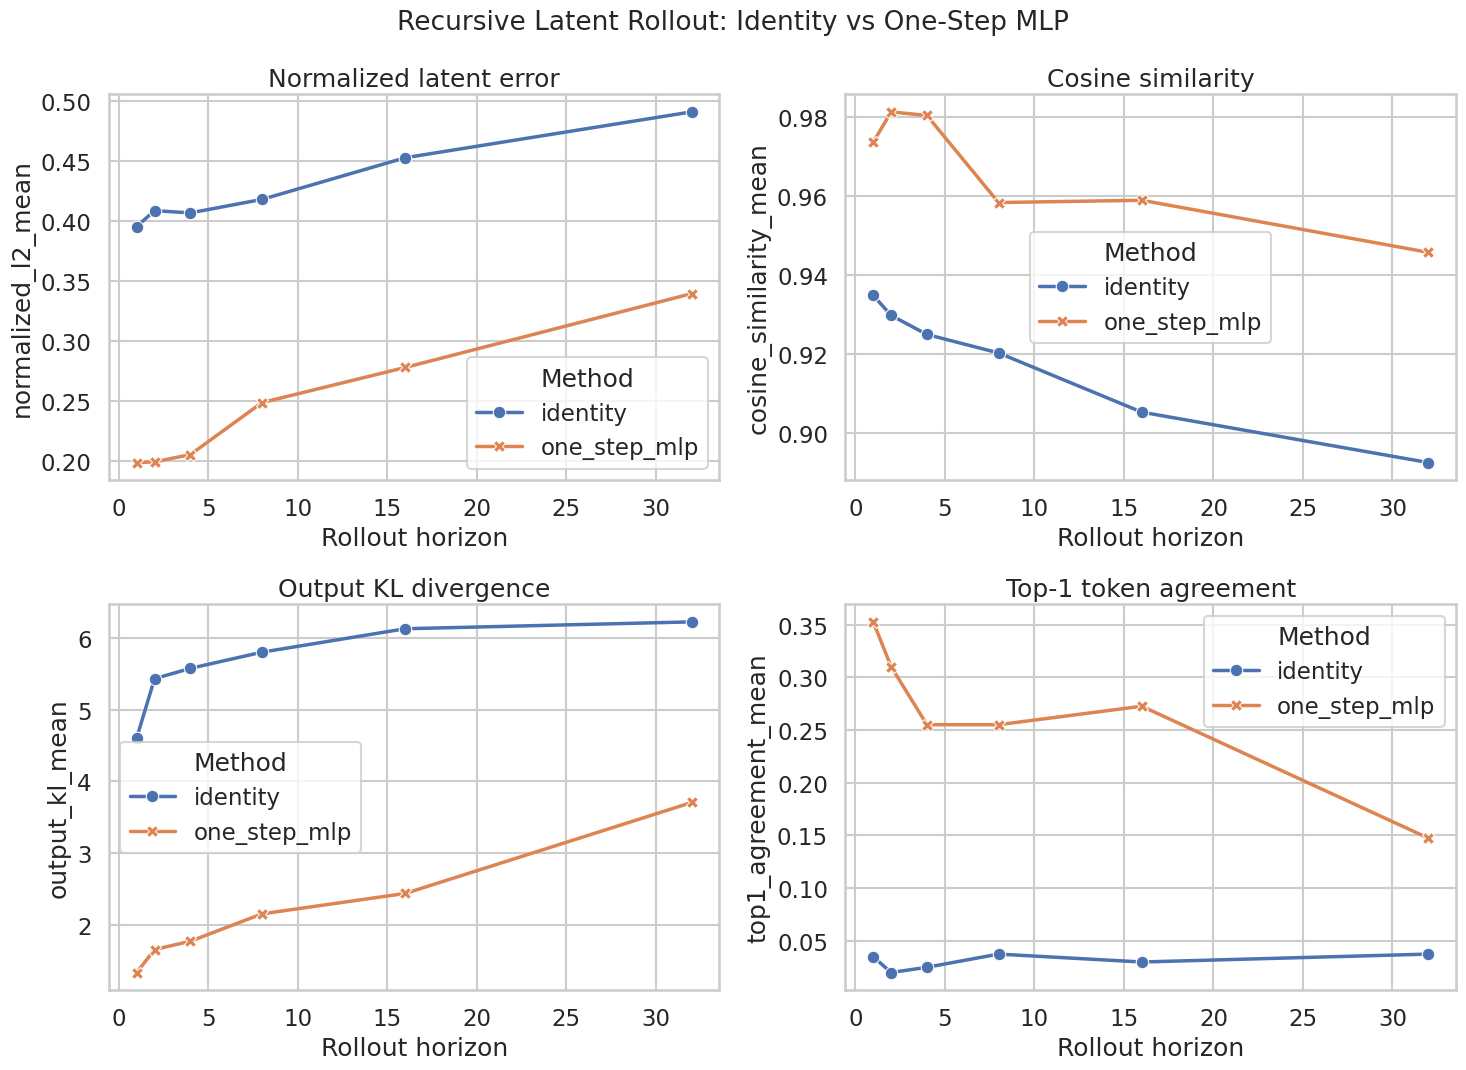

In [18]:
sns.set_theme(
    style="whitegrid",
    context="talk",
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 11),
)

plot_specs = [
    (
        "normalized_l2_mean",
        "Normalized latent error",
    ),
    (
        "cosine_similarity_mean",
        "Cosine similarity",
    ),
    (
        "output_kl_mean",
        "Output KL divergence",
    ),
    (
        "top1_agreement_mean",
        "Top-1 token agreement",
    ),
]

for axis, (metric, title) in zip(
    axes.flatten(),
    plot_specs,
):
    sns.lineplot(
        data=summary_df,
        x="horizon",
        y=metric,
        hue="method",
        style="method",
        markers=True,
        dashes=False,
        linewidth=2.5,
        ax=axis,
    )

    axis.set_title(title)
    axis.set_xlabel("Rollout horizon")
    axis.legend(title="Method")

figure.suptitle(
    "Recursive Latent Rollout: Identity vs One-Step MLP",
    fontsize=19,
)

figure.tight_layout()
plt.show()

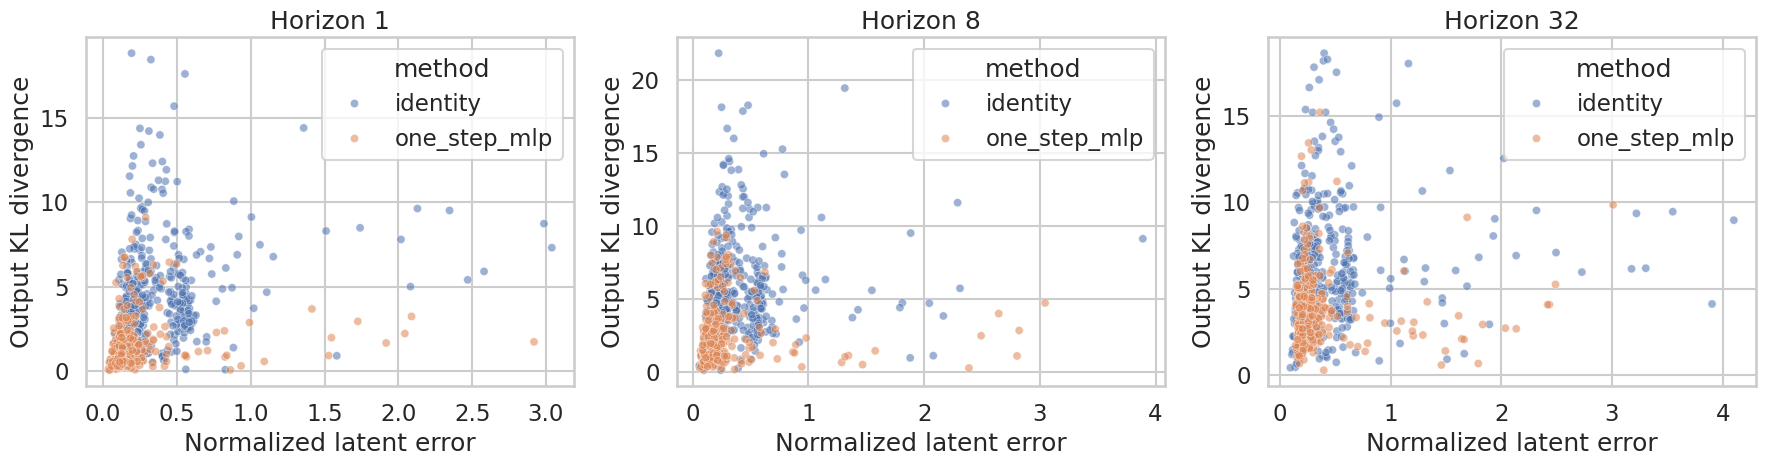

In [19]:
scatter_data = sample_df[
    sample_df["horizon"].isin(
        [1, 8, 32]
    )
].copy()

scatter_figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

for axis, horizon in zip(
    axes,
    [1, 8, 32],
):
    horizon_data = scatter_data[
        scatter_data["horizon"]
        == horizon
    ]

    sns.scatterplot(
        data=horizon_data,
        x="normalized_l2",
        y="output_kl",
        hue="method",
        alpha=0.55,
        s=35,
        ax=axis,
    )

    axis.set_title(
        f"Horizon {horizon}"
    )

    axis.set_xlabel(
        "Normalized latent error"
    )

    axis.set_ylabel(
        "Output KL divergence"
    )

scatter_figure.tight_layout()
plt.show()

In [20]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

In [21]:
summary_path = (
    TABLE_DIRECTORY
    / "rollout_comparison_summary.csv"
)

sample_path = (
    TABLE_DIRECTORY
    / "rollout_comparison_samples.csv"
)

improvement_path = (
    TABLE_DIRECTORY
    / "rollout_improvement.csv"
)

figure_path = (
    FIGURE_DIRECTORY
    / "rollout_comparison.png"
)

scatter_path = (
    FIGURE_DIRECTORY
    / "latent_error_vs_output_kl.png"
)

summary_df.to_csv(
    summary_path,
    index=False,
)

sample_df.to_csv(
    sample_path,
    index=False,
)

improvement_df.to_csv(
    improvement_path,
    index=False,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

scatter_figure.savefig(
    scatter_path,
    dpi=200,
    bbox_inches="tight",
)

print("Saved:", summary_path)
print("Saved:", improvement_path)
print("Saved:", figure_path)
print("Saved:", scatter_path)

Saved: /content/drive/MyDrive/ma2288_nextlat/results/tables/rollout_comparison_summary.csv
Saved: /content/drive/MyDrive/ma2288_nextlat/results/tables/rollout_improvement.csv
Saved: /content/drive/MyDrive/ma2288_nextlat/results/figures/rollout_comparison.png
Saved: /content/drive/MyDrive/ma2288_nextlat/results/figures/latent_error_vs_output_kl.png
